## 📦 Import Library

In [42]:
# ─── Core ───────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ─── Preprocessing & Dimensionality Reduction ───────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

# ─── Clustering ─────────────────────────────────────────────────────────
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage

# ─── Association Rules ──────────────────────────────────────────────────
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# ─── Visualisasi ────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
RANDOM_STATE = 42

print("✅ Semua library berhasil di-import!")

✅ Semua library berhasil di-import!


---
# 🔷 TASK 1 – PCA & Eksplorasi Data
---

## 1.1 Load & Eksplorasi Awal Data

In [43]:
df = pd.read_csv('client_customer_data.csv')

print(f"Shape: {df.shape}")
print(f"\nInfo:")
df.info()

Shape: (683, 8)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 683 entries, 0 to 682
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               683 non-null    str    
 1   age                       675 non-null    float64
 2   monthly_income_idr        676 non-null    float64
 3   monthly_spend_idr         683 non-null    int64  
 4   app_usage_time_hrs        683 non-null    int64  
 5   support_tickets_opened    683 non-null    int64  
 6   website_visits_per_month  683 non-null    int64  
 7   customer_tenure_months    683 non-null    int64  
dtypes: float64(2), int64(5), str(1)
memory usage: 42.8 KB


In [44]:
df.head(10)

,customer_id,age,monthly_income_idr,monthly_spend_idr,app_usage_time_hrs,support_tickets_opened,website_visits_per_month,customer_tenure_months
0,CUST-16265,36.0,9692743.0,1610268,12,3,19,23
1,CUST-74820,31.0,24628519.0,11472471,27,1,2,24
2,CUST-93104,23.0,4791743.0,203355,1,0,12,22
3,CUST-12747,44.0,20743066.0,9253882,34,1,16,15
4,CUST-76803,36.0,13147581.0,3454354,19,3,25,3
5,CUST-97313,24.0,6586644.0,356840,3,0,4,25
6,CUST-33483,19.0,6795513.0,517113,1,0,7,44
7,CUST-79479,36.0,12798669.0,3370928,11,2,4,2
8,CUST-81211,43.0,13558019.0,2720405,9,2,2,10
9,CUST-99789,25.0,4564685.0,453531,1,0,8,21


In [45]:
df.describe().round(2)

,age,monthly_income_idr,monthly_spend_idr,app_usage_time_hrs,support_tickets_opened,website_visits_per_month,customer_tenure_months
count,675.00,676.00,683.00,683.00,683.00,683.00,683.00
mean,31.55,11649919.83,3579137.20,28.25,1.13,14.90,23.84
std,10.20,6890175.57,3695076.32,382.26,1.10,8.53,13.56
min,18.00,4067642.00,-500000.00,1.00,0.00,1.00,1.00
25%,24.00,6573091.25,647831.50,4.00,0.00,7.00,13.00
50%,29.00,10480081.50,2724744.00,12.00,1.00,15.00,23.00
75%,40.00,13092776.50,4269932.00,17.00,2.00,23.00,36.00
max,150.00,34984609.00,14983593.00,9999.00,3.00,29.00,47.00


## 1.2 Data Cleaning

In [46]:
# ── Cek Missing Values ──────────────────────────────────────────────────
print("=== Missing Values ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

=== Missing Values ===
                    Missing Count  Missing %
age                             8       1.17
monthly_income_idr              7       1.02


In [47]:
# ── Cek Outlier Ekstrem ──────────────────────────────────────────────────
print("=== Deteksi Outlier Ekstrem ===")
print(f"Age max: {df['age'].max()} → Row dengan age > 80:")
print(df[df['age'] > 80][['customer_id', 'age']])

print(f"\nMonthly Income max: {df['monthly_income_idr'].max():,.0f}")
print(f"Monthly Spend max: {df['monthly_spend_idr'].max():,.0f}")

=== Deteksi Outlier Ekstrem ===
Age max: 150.0 → Row dengan age > 80:
   customer_id    age
45  CUST-99912  150.0

Monthly Income max: 34,984,609
Monthly Spend max: 14,983,593


In [48]:
# ── Cleaning Pipeline ───────────────────────────────────────────────────

# 1. Hapus outlier age yang tidak masuk akal (age = 150 → data error)
df_clean = df[df['age'] <= 100].copy()
print(f"Rows setelah drop outlier age: {len(df_clean)} (dari {len(df)})")

# 2. Pisahkan fitur numerik (customer_id tidak dipakai untuk clustering)
feature_cols = ['age', 'monthly_income_idr', 'monthly_spend_idr',
                'app_usage_time_hrs', 'support_tickets_opened',
                'website_visits_per_month', 'customer_tenure_months']

X_raw = df_clean[feature_cols].copy()

# 3. Imputasi missing values dengan median (lebih robust terhadap outlier)
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_raw)
X_imputed = pd.DataFrame(X_imputed, columns=feature_cols)

# 4. Handle outlier ekstrem pada app_usage_time_hrs menggunakan IQR capping
# Nilai 9999 jam/bulan jelas data error (max logis: 24*31 = 744 jam)
Q1 = X_imputed['app_usage_time_hrs'].quantile(0.25)
Q3 = X_imputed['app_usage_time_hrs'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 3 * IQR  # gunakan 3*IQR untuk conservative capping
outlier_count = (X_imputed['app_usage_time_hrs'] > upper_fence).sum()
X_imputed['app_usage_time_hrs'] = X_imputed['app_usage_time_hrs'].clip(upper=upper_fence)
print(f"Outlier app_usage_time_hrs di-cap ke {upper_fence:.0f} jam ({outlier_count} baris)")

print(f"\nMissing values setelah imputasi: {X_imputed.isnull().sum().sum()}")
print("\nData siap diproses!")

Rows setelah drop outlier age: 674 (dari 683)
Outlier app_usage_time_hrs di-cap ke 56 jam (1 baris)

Missing values setelah imputasi: 0

Data siap diproses!


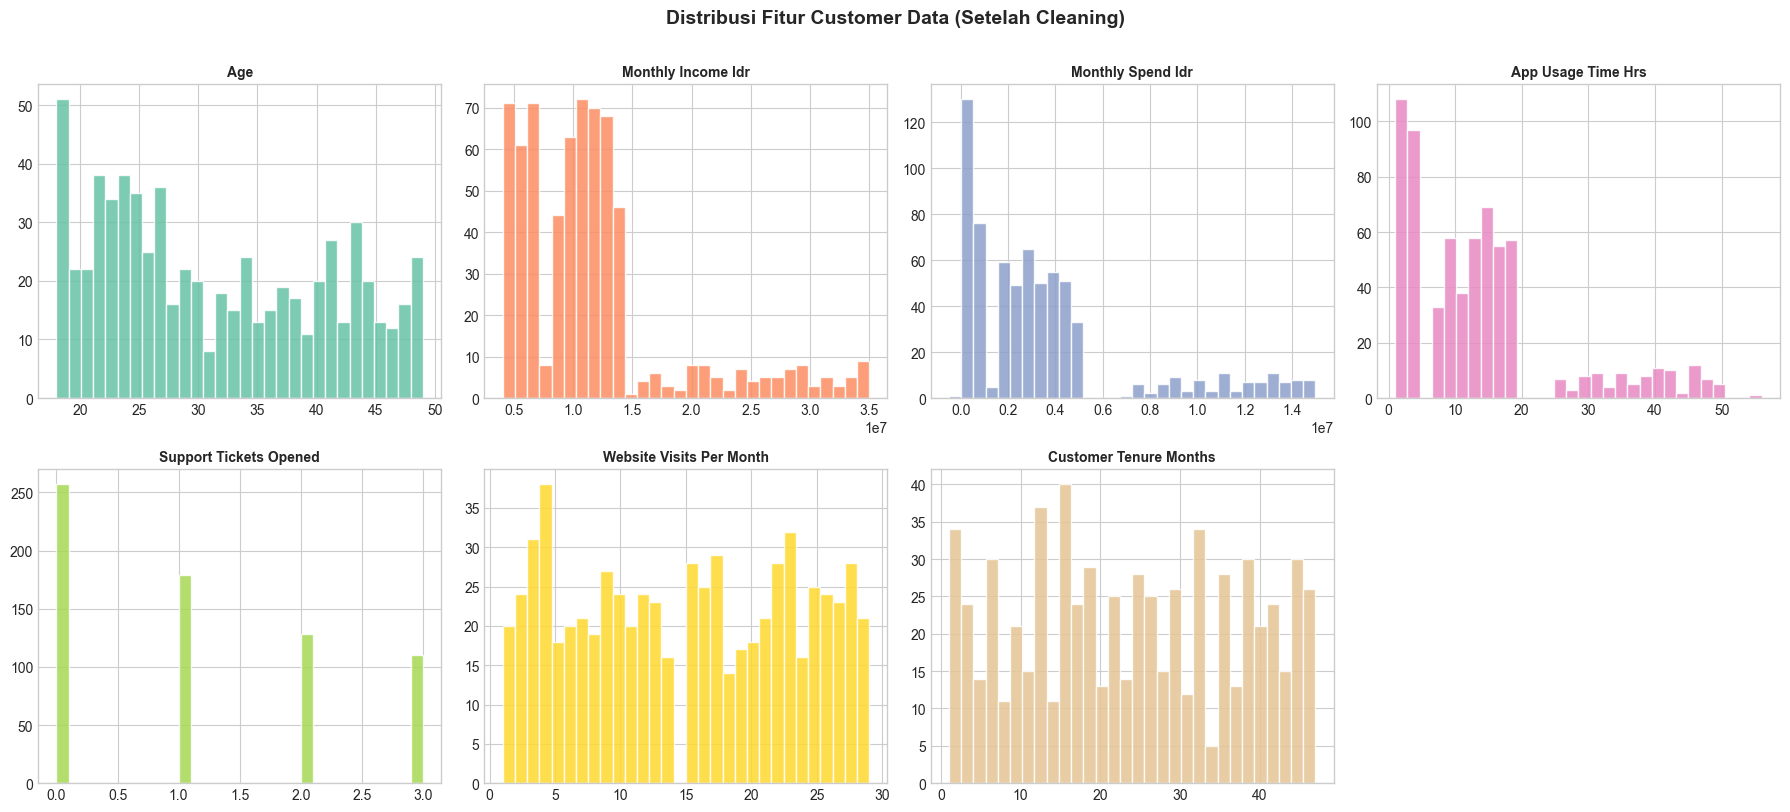

In [49]:
# ── Distribusi Tiap Fitur ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

colors = sns.color_palette('Set2', len(feature_cols))

for i, col in enumerate(feature_cols):
    axes[i].hist(X_imputed[col], bins=30, color=colors[i], edgecolor='white', alpha=0.85)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')

# Matikan axes kosong
for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribusi Fitur Customer Data (Setelah Cleaning)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 1.3 Feature Engineering: Spend Ratio

> **Insight:** Rasio pengeluaran terhadap income adalah sinyal penting untuk profiling — dua orang dengan income berbeda tapi spend ratio sama punya perilaku konsumtif yang mirip.

In [50]:
# Tambah fitur turunan: spend ratio
X_imputed['spend_ratio'] = X_imputed['monthly_spend_idr'] / X_imputed['monthly_income_idr']

# Clip ke [0,1] untuk menghindari nilai > 1 akibat noise
X_imputed['spend_ratio'] = X_imputed['spend_ratio'].clip(0, 1)

all_features = feature_cols + ['spend_ratio']
print(f"Total fitur: {len(all_features)}")
print(X_imputed[all_features].describe().round(3))

Total fitur: 8
           age  monthly_income_idr  monthly_spend_idr  app_usage_time_hrs  \
count  674.000        6.740000e+02       6.740000e+02             674.000   
mean    31.369        1.164166e+07       3.589035e+06              13.724   
std      9.128        6.827290e+06       3.692060e+06              11.946   
min     18.000        4.067642e+06      -5.000000e+05               1.000   
25%     24.000        6.590770e+06       6.505022e+05               4.000   
50%     29.000        1.048520e+07       2.764962e+06              12.000   
75%     40.000        1.306024e+07       4.281874e+06              17.000   
max     49.000        3.498461e+07       1.498359e+07              56.000   

       support_tickets_opened  website_visits_per_month  \
count                 674.000                   674.000   
mean                    1.135                    14.872   
std                     1.099                     8.530   
min                     0.000                     1.000

## 1.4 Standardisasi & Principal Component Analysis (PCA)

In [51]:
# ── Standardisasi ──────────────────────────────────────────────────────
# PCA sensitif terhadap skala → wajib StandardScaler dulu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed[all_features])

print("Statistik setelah scaling:")
print(f"  Mean (approx 0): {X_scaled.mean(axis=0).round(4)}")
print(f"  Std  (approx 1): {X_scaled.std(axis=0).round(4)}")

Statistik setelah scaling:
  Mean (approx 0): [-0. -0.  0. -0.  0. -0. -0. -0.]
  Std  (approx 1): [1. 1. 1. 1. 1. 1. 1. 1.]


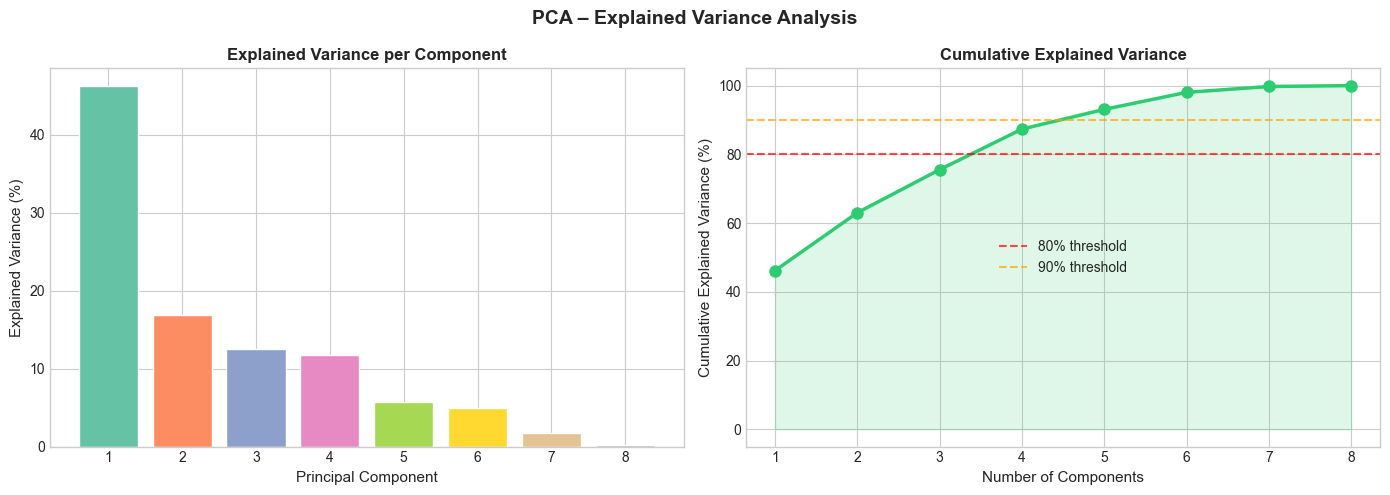


=== Explained Variance per Component ===
  PC1: 46.22% | Kumulatif: 46.22%
  PC2: 16.83% | Kumulatif: 63.05%
  PC3: 12.52% | Kumulatif: 75.57%
  PC4: 11.80% | Kumulatif: 87.36%
  PC5: 5.73% | Kumulatif: 93.09%
  PC6: 4.95% | Kumulatif: 98.04%
  PC7: 1.71% | Kumulatif: 99.75%
  PC8: 0.25% | Kumulatif: 100.00%


In [52]:
# ── PCA: Analisis Explained Variance ────────────────────────────────────
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Individual explained variance
axes[0].bar(range(1, len(explained_var)+1), explained_var * 100,
            color=sns.color_palette('Set2'), edgecolor='white')
axes[0].set_xlabel('Principal Component', fontsize=11)
axes[0].set_ylabel('Explained Variance (%)', fontsize=11)
axes[0].set_title('Explained Variance per Component', fontsize=12, fontweight='bold')
axes[0].set_xticks(range(1, len(explained_var)+1))

# Plot 2: Cumulative explained variance
axes[1].plot(range(1, len(cumulative_var)+1), cumulative_var * 100,
             'o-', color='#2ecc71', linewidth=2.5, markersize=8)
axes[1].axhline(y=80, color='red', linestyle='--', alpha=0.7, label='80% threshold')
axes[1].axhline(y=90, color='orange', linestyle='--', alpha=0.7, label='90% threshold')
axes[1].fill_between(range(1, len(cumulative_var)+1), cumulative_var * 100, alpha=0.15, color='#2ecc71')
axes[1].set_xlabel('Number of Components', fontsize=11)
axes[1].set_ylabel('Cumulative Explained Variance (%)', fontsize=11)
axes[1].set_title('Cumulative Explained Variance', fontsize=12, fontweight='bold')
axes[1].set_xticks(range(1, len(cumulative_var)+1))
axes[1].legend()

plt.suptitle('PCA – Explained Variance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n=== Explained Variance per Component ===")
for i, (ev, cv) in enumerate(zip(explained_var, cumulative_var)):
    print(f"  PC{i+1}: {ev*100:.2f}% | Kumulatif: {cv*100:.2f}%")

In [53]:
# ── Terapkan PCA dengan 3 Komponen ──────────────────────────────────────
# Dipilih 3 PC karena:
# 1. Memberikan variance yang cukup representatif
# 2. Lebih informatif dari 2 PC untuk hierarchical clustering
# 3. Memungkinkan visualisasi 2D (PC1 vs PC2) maupun 3D

N_COMPONENTS = 3
pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

X_pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(N_COMPONENTS)])

total_var = pca.explained_variance_ratio_.sum() * 100
print(f"Variance tertangkap oleh {N_COMPONENTS} PC: {total_var:.2f}%")
print(f"Shape data setelah PCA: {X_pca_df.shape}")
print("\nPreview:")
print(X_pca_df.head())

Variance tertangkap oleh 3 PC: 75.57%
Shape data setelah PCA: (674, 3)

Preview:
        PC1       PC2       PC3
0 -0.315695  1.809085 -0.014198
1  3.044994 -1.591954  0.089876
2 -2.433985 -0.822621 -0.069834
3  3.107225 -0.158546 -0.747591
4  0.658416  1.824463 -1.621343


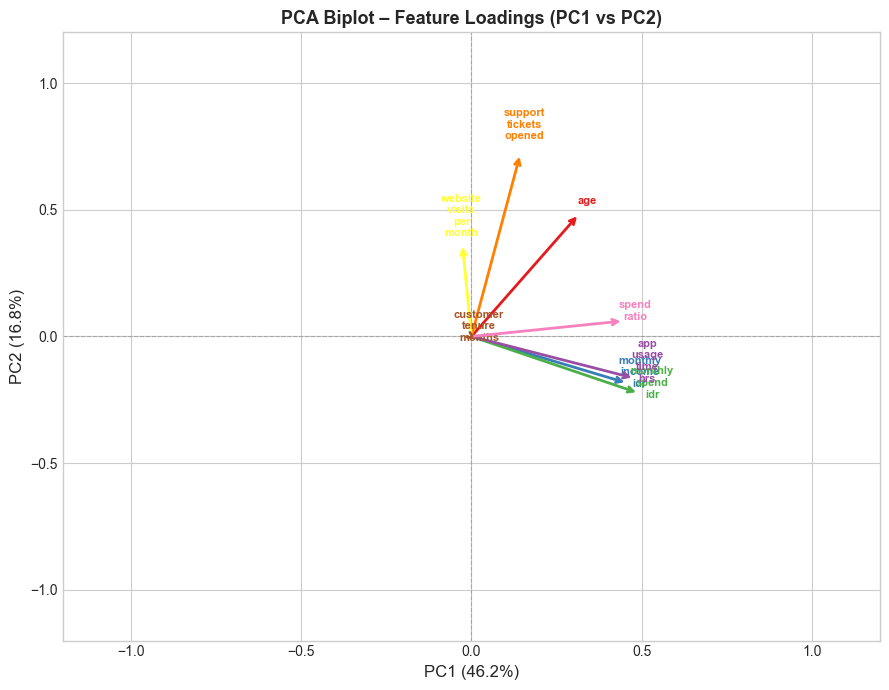


=== Loading Factors ===
                            PC1    PC2    PC3
age                       0.316  0.482  0.037
monthly_income_idr        0.457 -0.184 -0.055
monthly_spend_idr         0.491 -0.224 -0.028
app_usage_time_hrs        0.478 -0.165 -0.035
support_tickets_opened    0.144  0.720  0.044
website_visits_per_month -0.027  0.366 -0.159
customer_tenure_months    0.021 -0.016  0.983
spend_ratio               0.446  0.061  0.029


In [54]:
# ── PCA Biplot: Loading Factors ──────────────────────────────────────────
# Memperlihatkan kontribusi tiap fitur terhadap PC1 dan PC2
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(N_COMPONENTS)],
    index=all_features
)

fig, ax = plt.subplots(figsize=(9, 7))

colors_feat = sns.color_palette('Set1', len(all_features))
for i, feat in enumerate(all_features):
    ax.annotate('', xy=(loadings.loc[feat, 'PC1'], loadings.loc[feat, 'PC2']),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=colors_feat[i], lw=2))
    ax.text(loadings.loc[feat, 'PC1'] * 1.08,
            loadings.loc[feat, 'PC2'] * 1.08,
            feat.replace('_', '\n'), fontsize=8, ha='center', color=colors_feat[i],
            fontweight='bold')

ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax.set_title('PCA Biplot – Feature Loadings (PC1 vs PC2)', fontsize=13, fontweight='bold')
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)

plt.tight_layout()
plt.show()

print("\n=== Loading Factors ===")
print(loadings.round(3))

---
# 🔷 TASK 2 – Segmentasi Pelanggan (K-Means & Hierarchical)
---

## 2.1 Mencari K Optimal – Elbow Method & Silhouette Score

In [55]:
# ── Elbow Method + Silhouette Score ────────────────────────────────────
K_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X_pca_df)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_pca_df, labels))

print("K  | Inertia        | Silhouette Score")
print("-" * 45)
for k, inertia, sil in zip(K_range, inertias, silhouette_scores):
    marker = " ← OPTIMAL" if sil == max(silhouette_scores) else ""
    print(f"K={k} | {inertia:13,.2f} | {sil:.4f}{marker}")

K  | Inertia        | Silhouette Score
---------------------------------------------
K=2 |      2,306.74 | 0.5166 ← OPTIMAL
K=3 |      1,122.07 | 0.5149
K=4 |        832.69 | 0.4561
K=5 |        680.83 | 0.4268
K=6 |        577.59 | 0.4151
K=7 |        503.32 | 0.3843
K=8 |        445.06 | 0.3678
K=9 |        410.58 | 0.3618
K=10 |        380.74 | 0.3690


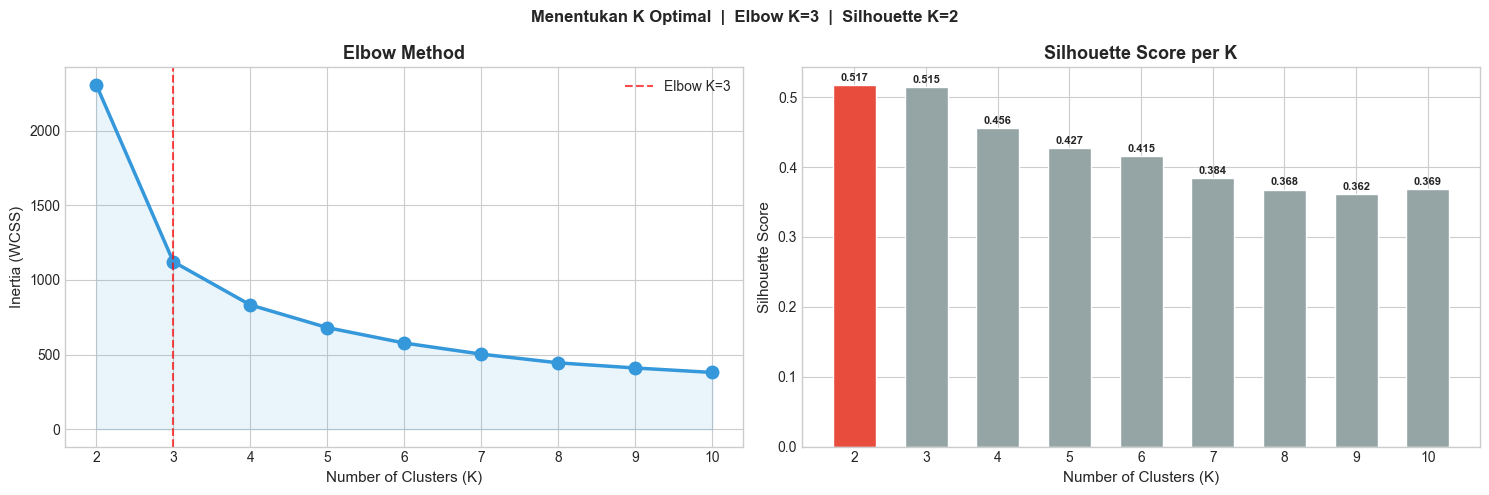


✅ K optimal berdasarkan Elbow    : K = 3
✅ K optimal berdasarkan Silhouette: K = 2 (Score: 0.5166)


In [56]:
# ── Visualisasi Elbow + Silhouette ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Elbow Plot
axes[0].plot(list(K_range), inertias, 'o-', color='#3498db', linewidth=2.5, markersize=9)
axes[0].fill_between(list(K_range), inertias, alpha=0.1, color='#3498db')

# Cari elbow (titik perubahan kelengkungan terbesar)
optimal_k_elbow = None
max_diff2 = 0
inertias_arr = np.array(inertias)
for i in range(1, len(inertias_arr)-1):
    d2 = abs(inertias_arr[i-1] - 2*inertias_arr[i] + inertias_arr[i+1])
    if d2 > max_diff2:
        max_diff2 = d2
        optimal_k_elbow = list(K_range)[i]

optimal_k_sil = list(K_range)[np.argmax(silhouette_scores)]

axes[0].axvline(optimal_k_elbow, color='red', linestyle='--', alpha=0.7,
                label=f'Elbow K={optimal_k_elbow}')
axes[0].set_title('Elbow Method', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)', fontsize=11)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=11)
axes[0].set_xticks(list(K_range))
axes[0].legend()

# Silhouette Plot
bar_colors = ['#e74c3c' if k == optimal_k_sil else '#95a5a6' for k in K_range]
bars = axes[1].bar(list(K_range), silhouette_scores, color=bar_colors, edgecolor='white', width=0.6)
axes[1].set_title('Silhouette Score per K', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)', fontsize=11)
axes[1].set_ylabel('Silhouette Score', fontsize=11)
axes[1].set_xticks(list(K_range))
for bar, score in zip(bars, silhouette_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003,
                 f'{score:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle(f'Menentukan K Optimal  |  Elbow K={optimal_k_elbow}  |  Silhouette K={optimal_k_sil}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n✅ K optimal berdasarkan Elbow    : K = {optimal_k_elbow}")
print(f"✅ K optimal berdasarkan Silhouette: K = {optimal_k_sil} (Score: {max(silhouette_scores):.4f})")

In [57]:
# ── Keputusan K Final ────────────────────────────────────────────────────
# Dari Elbow: K=3 | Dari Silhouette: K=2
# Kedua metode memberikan signal yang berbeda → pertimbangkan konteks bisnis.
#
# K=2 secara matematis memiliki Silhouette tertinggi, tapi dari perspektif
# marketing, 2 segmen terlalu kasar untuk merancang kampanye yang targeted.
# K=3 dipilih karena:
#   1. Elbow method menunjukkan K=3 sebagai titik infleksi utama
#   2. Silhouette K=3 (0.51) masih sangat baik — selisih kecil dari K=2
#   3. Memberikan granularitas bisnis yang lebih actionable
#   4. Best practice segmentasi pelanggan: minimal 3 tier (premium, mid, budget)

K_FINAL = max(optimal_k_elbow, 3)  # minimal 3 untuk meaningful segmentation
print(f"🎯 K Final yang digunakan: K = {K_FINAL}")
print(f"   Silhouette Score K={K_FINAL}: {silhouette_scores[K_FINAL - 2]:.4f}")
print(f"   (Dipilih K=3 atas pertimbangan bisnis: granularitas segmentasi yang lebih actionable)")

🎯 K Final yang digunakan: K = 3
   Silhouette Score K=3: 0.5149
   (Dipilih K=3 atas pertimbangan bisnis: granularitas segmentasi yang lebih actionable)


## 2.2 K-Means Clustering

In [58]:
# ── Fit K-Means dengan K optimal ────────────────────────────────────────
kmeans_final = KMeans(
    n_clusters=K_FINAL,
    init='k-means++',      # Inisialisasi lebih stabil
    n_init=20,             # Jalankan 20x dan ambil hasil terbaik
    max_iter=500,
    random_state=RANDOM_STATE
)

# Training model
cluster_labels = kmeans_final.fit_predict(X_pca_df[['PC1', 'PC2', 'PC3']])

# Tambahkan label cluster ke dataframe PCA
X_pca_df['Cluster'] = cluster_labels

# Tambahkan label cluster ke dataframe asli
df_clean_indexed = df_clean.reset_index(drop=True)
df_clean_indexed['Cluster'] = cluster_labels

# ── Evaluation Metrics ──────────────────────────────────────────────────
sil_final = silhouette_score(
    X_pca_df[['PC1', 'PC2', 'PC3']],
    cluster_labels
)

dbi_final = davies_bouldin_score(
    X_pca_df[['PC1', 'PC2', 'PC3']],
    cluster_labels
)

ch_final = calinski_harabasz_score(
    X_pca_df[['PC1', 'PC2', 'PC3']],
    cluster_labels
)

# ── Hasil Evaluasi ──────────────────────────────────────────────────────
print("=== Evaluation Metrics K-Means ===")

print(f"Silhouette Score       : {sil_final:.4f}")
print(f"Davies-Bouldin Index   : {dbi_final:.4f}")
print(f"Calinski-Harabasz Score: {ch_final:,.2f}")
print(f"Inertia (WCSS)         : {kmeans_final.inertia_:,.2f}")

print(f"\n K Final yang digunakan: K = {K_FINAL}")

print("\n=== Distribusi Cluster ===")
print(df_clean_indexed['Cluster'].value_counts().sort_index())

=== Evaluation Metrics K-Means ===
Silhouette Score       : 0.5149
Davies-Bouldin Index   : 0.7259
Calinski-Harabasz Score: 882.81
Inertia (WCSS)         : 1,122.07

 K Final yang digunakan: K = 3

=== Distribusi Cluster ===
Cluster
0    359
1    215
2    100
Name: count, dtype: int64


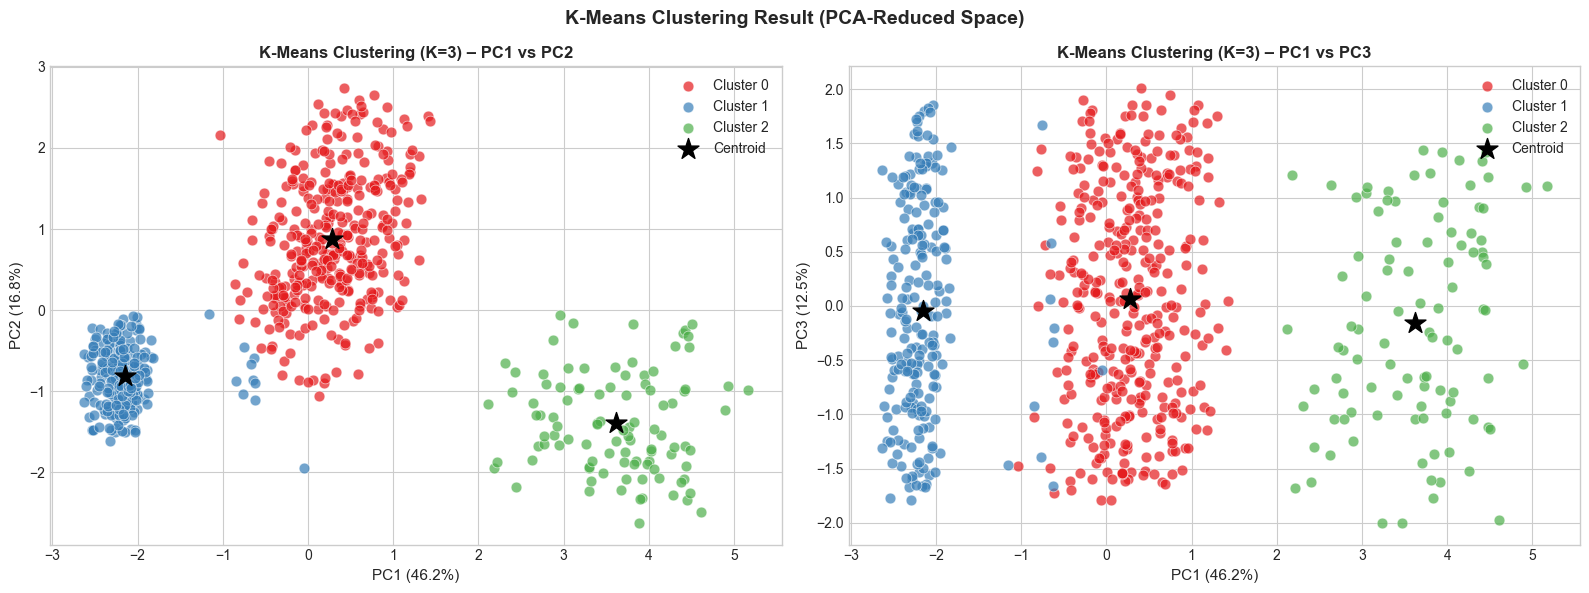

In [59]:
# ── Visualisasi K-Means (PC1 vs PC2) ────────────────────────────────────
cluster_palette = sns.color_palette('Set1', K_FINAL)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: PC1 vs PC2
for c in range(K_FINAL):
    mask = cluster_labels == c
    axes[0].scatter(
        X_pca_df.loc[mask, 'PC1'],
        X_pca_df.loc[mask, 'PC2'],
        c=[cluster_palette[c]], label=f'Cluster {c}',
        alpha=0.7, s=60, edgecolors='white', linewidths=0.5
    )

# Plot centroids
centroids = kmeans_final.cluster_centers_
axes[0].scatter(centroids[:, 0], centroids[:, 1],
                s=250, c='black', marker='*', zorder=5, label='Centroid')
axes[0].set_title(f'K-Means Clustering (K={K_FINAL}) – PC1 vs PC2', fontsize=12, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
axes[0].legend()

# Plot 2: PC1 vs PC3
for c in range(K_FINAL):
    mask = cluster_labels == c
    axes[1].scatter(
        X_pca_df.loc[mask, 'PC1'],
        X_pca_df.loc[mask, 'PC3'],
        c=[cluster_palette[c]], label=f'Cluster {c}',
        alpha=0.7, s=60, edgecolors='white', linewidths=0.5
    )

axes[1].scatter(centroids[:, 0], centroids[:, 2],
                s=250, c='black', marker='*', zorder=5, label='Centroid')
axes[1].set_title(f'K-Means Clustering (K={K_FINAL}) – PC1 vs PC3', fontsize=12, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
axes[1].set_ylabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)', fontsize=11)
axes[1].legend()

plt.suptitle('K-Means Clustering Result (PCA-Reduced Space)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 2.3 Profiling Cluster – Interpretasi

In [1]:
# ── Rata-rata Fitur per Cluster ──────────────────────────────────────────
cluster_profile = df_clean_indexed.groupby('Cluster')[feature_cols].mean().round(2)

# Tambah spend_ratio
df_clean_indexed['spend_ratio'] = (df_clean_indexed['monthly_spend_idr'] / 
                                    df_clean_indexed['monthly_income_idr']).clip(0, 1)
cluster_profile['spend_ratio'] = df_clean_indexed.groupby('Cluster')['spend_ratio'].mean().round(3)
cluster_profile['count'] = df_clean_indexed.groupby('Cluster').size()

print("=== Profil Rata-Rata per Cluster ===")
display(cluster_profile)

NameError: name 'df_clean_indexed' is not defined

In [ ]:
# ── Penamaan Cluster Berdasarkan Profil ──────────────────────────────────
# Logika penamaan: gunakan kombinasi income, spend, app_usage, dan spend_ratio
# untuk memberi nama yang deskriptif dan logis

cluster_names = {}

for c in cluster_profile.index:

    income = cluster_profile.loc[c, 'monthly_income_idr']
    spend = cluster_profile.loc[c, 'monthly_spend_idr']
    usage = cluster_profile.loc[c, 'app_usage_time_hrs']
    ratio = cluster_profile.loc[c, 'spend_ratio']
    age = cluster_profile.loc[c, 'age']

    # ── Premium / High Value ──────────────────────────────────────
    if income > 20000000 and spend > 8000000:
        cluster_names[c] = "Premium Power Users"

    # ── Young Highly Active Users ─────────────────────────────────
    elif age < 25 and usage > 40:
        cluster_names[c] = "Young Digital Enthusiasts"

    # ── Regular Mainstream Customers ──────────────────────────────
    else:
        cluster_names[c] = "Mainstream Customers"

# ── Tampilkan Hasil ───────────────────────────────────────────────

print("=== Nama Cluster ===\n")

for k, v in cluster_names.items():

    count = int(cluster_profile.loc[k, 'count'])

    print(f"Cluster {k}")
    print(f"→ {v}")
    print(f"→ Total Customer: {count}\n")

=== Nama Cluster ===
  Cluster 0 → Established Professionals (n=359)
  Cluster 1 → Budget-Conscious Customers (n=215)
  Cluster 2 → High Value Loyalists (n=100)


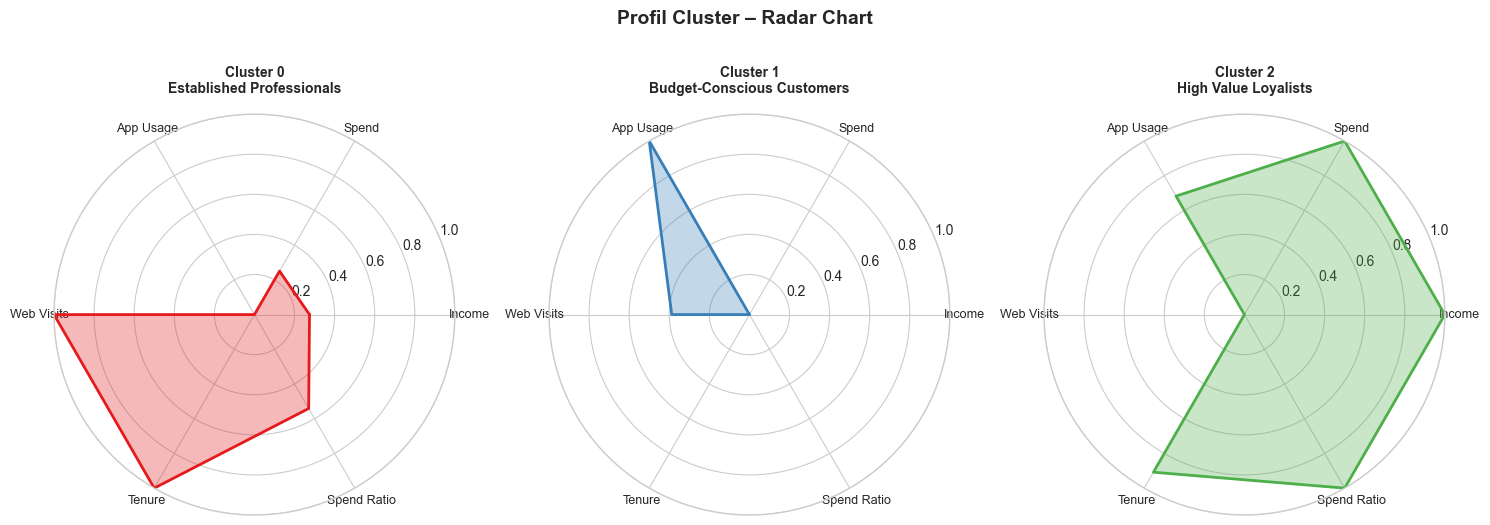

In [62]:
# ── Radar/Spider Chart per Cluster ──────────────────────────────────────
from matplotlib.patches import FancyArrowPatch
import math

radar_features = ['monthly_income_idr', 'monthly_spend_idr', 'app_usage_time_hrs',
                  'website_visits_per_month', 'customer_tenure_months', 'spend_ratio']
radar_labels = ['Income', 'Spend', 'App Usage', 'Web Visits', 'Tenure', 'Spend Ratio']

# Normalisasi 0-1 per fitur
radar_data = cluster_profile[radar_features].copy()
radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min())

N = len(radar_features)
angles = [n / float(N) * 2 * math.pi for n in range(N)]
angles += angles[:1]  # close the polygon

fig, axes = plt.subplots(1, K_FINAL, figsize=(5*K_FINAL, 5), subplot_kw=dict(polar=True))
if K_FINAL == 1:
    axes = [axes]

for c, ax in enumerate(axes):
    values = radar_norm.loc[c].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, linestyle='solid', color=cluster_palette[c])
    ax.fill(angles, values, alpha=0.3, color=cluster_palette[c])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, fontsize=9)
    ax.set_title(f'Cluster {c}\n{cluster_names[c]}', size=10, fontweight='bold', pad=15)
    ax.set_ylim(0, 1)

plt.suptitle('Profil Cluster – Radar Chart', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

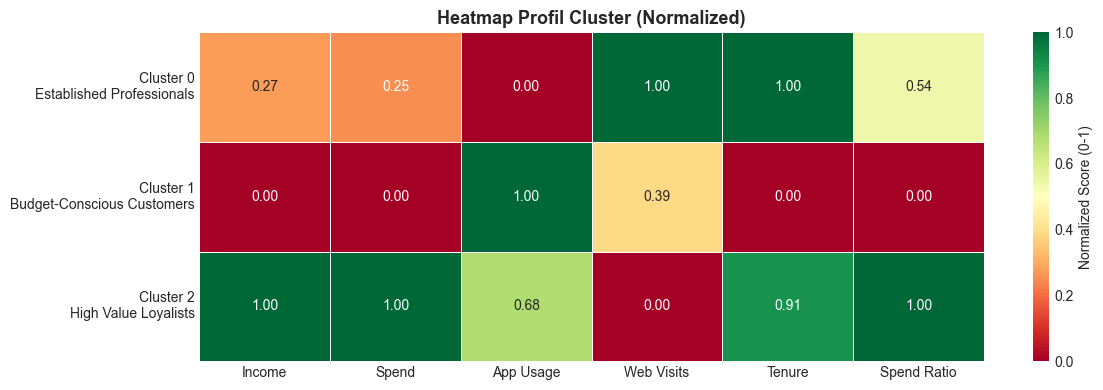

In [63]:
# ── Heatmap Profil Cluster ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))

heatmap_data = radar_norm[radar_features]
heatmap_data.index = [f'Cluster {c}\n{cluster_names[c]}' for c in heatmap_data.index]

sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Normalized Score (0-1)'},
            xticklabels=radar_labels)

ax.set_title('Heatmap Profil Cluster (Normalized)', fontsize=13, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 2.4 Hierarchical Clustering – Dendrogram

In [64]:
# ── Hierarchical Clustering ─────────────────────────────────────────────
# Gunakan subsample untuk dendrogram yang terbaca (683 rows → semua bisa dipake)
# Metode 'ward' meminimalkan total within-cluster variance (konsisten dengan K-Means)

# Gunakan sample maksimal 200 untuk readability dendrogram
np.random.seed(RANDOM_STATE)
sample_size = min(200, len(X_pca_df))
sample_idx = np.random.choice(len(X_pca_df), sample_size, replace=False)

X_sample = X_pca_df[['PC1', 'PC2', 'PC3']].iloc[sample_idx].values

# Linkage matrix
Z = linkage(X_sample, method='ward', metric='euclidean')

print(f"Hierarchical Clustering dijalankan pada {sample_size} sampel")
print(f"Metode: Ward | Metrik: Euclidean")

Hierarchical Clustering dijalankan pada 200 sampel
Metode: Ward | Metrik: Euclidean


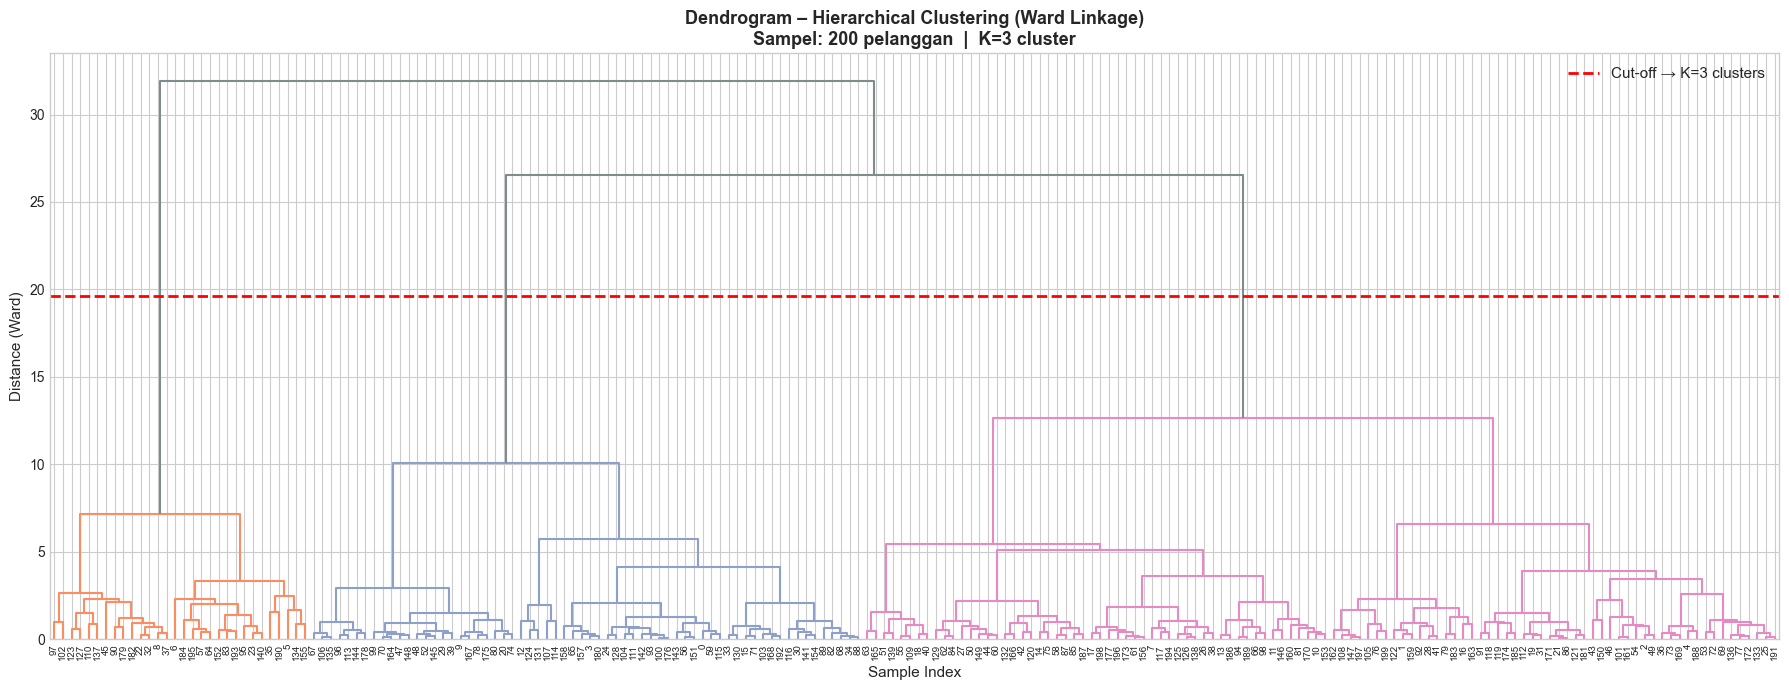

In [65]:
# ── Visualisasi Dendrogram ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 7))

# Color threshold: garis horizontal untuk memotong di K cluster
# Cari threshold otomatis berdasarkan K_FINAL
last_merge_distances = Z[-(K_FINAL-1):, 2]
color_threshold = (last_merge_distances[0] + Z[-(K_FINAL), 2]) / 2 if len(Z) >= K_FINAL else Z[-1, 2] * 0.7

dend = dendrogram(
    Z,
    ax=ax,
    color_threshold=color_threshold,
    above_threshold_color='#7f8c8d',
    leaf_rotation=90,
    leaf_font_size=7,
    show_leaf_counts=True
)

ax.axhline(y=color_threshold, color='red', linestyle='--', linewidth=2,
           label=f'Cut-off → K={K_FINAL} clusters')

ax.set_title(f'Dendrogram – Hierarchical Clustering (Ward Linkage)\n'
             f'Sampel: {sample_size} pelanggan  |  K={K_FINAL} cluster',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Sample Index', fontsize=11)
ax.set_ylabel('Distance (Ward)', fontsize=11)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

In [66]:
# ── Validasi: Silhouette Hierarchical vs K-Means ─────────────────────────
hc = AgglomerativeClustering(n_clusters=K_FINAL, linkage='ward')
hc_labels = hc.fit_predict(X_pca_df[['PC1','PC2','PC3']])

sil_hc = silhouette_score(X_pca_df[['PC1','PC2','PC3']], hc_labels)

print("=== Perbandingan Metode Clustering ===")
print(f"  K-Means Silhouette Score      : {sil_final:.4f}")
print(f"  Hierarchical Silhouette Score : {sil_hc:.4f}")
print(f"\n✅ Keduanya menggunakan K={K_FINAL} dan memberikan struktur pengelompokan yang konsisten.")

=== Perbandingan Metode Clustering ===
  K-Means Silhouette Score      : 0.5149
  Hierarchical Silhouette Score : 0.5126

✅ Keduanya menggunakan K=3 dan memberikan struktur pengelompokan yang konsisten.


---
# 🔷 TASK 3 – Analisa Pola Belanja (Market Basket Analysis – Apriori)
---

## 3.1 Load & Eksplorasi Transaction Data

In [67]:
df_trans = pd.read_csv('transaction_logs_client.csv')

print(f"Shape: {df_trans.shape}")
print(f"Unique Orders: {df_trans['order_id'].nunique()}")
print(f"Unique Products: {df_trans['product_name'].nunique()}")
print(f"\nProduk yang tersedia:")
print(df_trans['product_name'].value_counts())

Shape: (2590, 2)
Unique Orders: 1085
Unique Products: 9

Produk yang tersedia:
product_name
Smartphone             442
Laptop                 433
Phone Case             421
Wireless Mouse         372
Screen Protector       366
Mechanical Keyboard    211
TWS Earbuds            196
Smartwatch              78
Powerbank               71
Name: count, dtype: int64


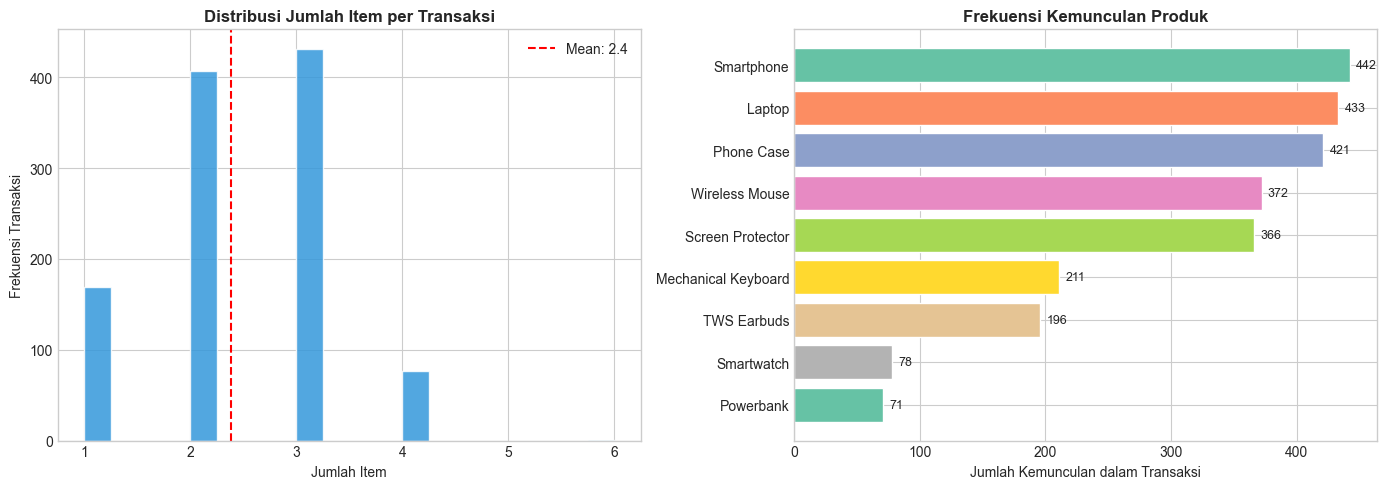


Rata-rata item per transaksi: 2.39
Median item per transaksi   : 2


In [68]:
# Distribusi jumlah item per transaksi
basket_size = df_trans.groupby('order_id')['product_name'].count()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram basket size
axes[0].hist(basket_size, bins=20, color='#3498db', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribusi Jumlah Item per Transaksi', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Jumlah Item')
axes[0].set_ylabel('Frekuensi Transaksi')
axes[0].axvline(basket_size.mean(), color='red', linestyle='--', label=f'Mean: {basket_size.mean():.1f}')
axes[0].legend()

# Frekuensi produk
prod_freq = df_trans['product_name'].value_counts()
colors_prod = sns.color_palette('Set2', len(prod_freq))
bars = axes[1].barh(prod_freq.index[::-1], prod_freq.values[::-1],
                    color=colors_prod[::-1], edgecolor='white')
axes[1].set_title('Frekuensi Kemunculan Produk', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Jumlah Kemunculan dalam Transaksi')
for bar, val in zip(bars, prod_freq.values[::-1]):
    axes[1].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nRata-rata item per transaksi: {basket_size.mean():.2f}")
print(f"Median item per transaksi   : {basket_size.median():.0f}")

## 3.2 Transformasi ke Format One-Hot (Transaction Matrix)

In [69]:
# ── Buat Transaction List ────────────────────────────────────────────────
transactions = df_trans.groupby('order_id')['product_name'].apply(list).tolist()

print(f"Total transaksi: {len(transactions)}")
print(f"\nContoh 3 transaksi pertama:")
for i, t in enumerate(transactions[:3]):
    print(f"  Transaksi {i+1}: {t}")

Total transaksi: 1085

Contoh 3 transaksi pertama:
  Transaksi 1: ['Laptop']
  Transaksi 2: ['Phone Case', 'TWS Earbuds', 'Screen Protector', 'Smartphone']
  Transaksi 3: ['Mechanical Keyboard', 'Laptop']


In [70]:
# ── Encode ke One-Hot Matrix ─────────────────────────────────────────────
te = TransactionEncoder()
te_array = te.fit_transform(transactions)
df_basket = pd.DataFrame(te_array, columns=te.columns_)

print(f"Shape basket matrix: {df_basket.shape}")
print(f"\nSupport individual produk:")
print((df_basket.mean() * 100).round(2).sort_values(ascending=False).astype(str) + '%')
print(f"\nPreview matrix:")
df_basket.head()

Shape basket matrix: (1085, 9)

Support individual produk:
Smartphone             40.74%
Laptop                 39.91%
Phone Case              38.8%
Wireless Mouse         34.29%
Screen Protector       33.73%
Mechanical Keyboard    19.45%
TWS Earbuds            18.06%
Smartwatch              7.19%
Powerbank               6.54%
dtype: str

Preview matrix:


,Laptop,Mechanical Keyboard,Phone Case,Powerbank,Screen Protector,Smartphone,Smartwatch,TWS Earbuds,Wireless Mouse
0,True,False,False,False,False,False,False,False,False
1,False,False,True,False,True,True,False,True,False
2,True,True,False,False,False,False,False,False,False
3,False,False,False,True,False,False,False,True,False
4,False,False,False,False,True,False,True,False,False


## 3.3 Algoritma Apriori – Frequent Itemsets

In [71]:
# ── Apriori: Temukan Frequent Itemsets ──────────────────────────────────
# min_support = 0.05 berarti kombinasi harus muncul di setidaknya 5% transaksi
# Cukup rendah untuk dataset dengan 9 produk dan 1085 transaksi

MIN_SUPPORT = 0.05

frequent_itemsets = apriori(
    df_basket,
    min_support=MIN_SUPPORT,
    use_colnames=True,
    max_len=3  # Fokus ke 1-3 item kombinasi
)

frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)
frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False)

print(f"Total frequent itemsets ditemukan: {len(frequent_itemsets)}")
print(f"\nDistribusi per panjang itemset:")
print(frequent_itemsets['length'].value_counts().sort_index())
print(f"\nTop 10 Frequent Itemsets:")
print(frequent_itemsets.head(10).to_string(index=False))

Total frequent itemsets ditemukan: 23

Distribusi per panjang itemset:
length
1    9
2    9
3    5
Name: count, dtype: int64

Top 10 Frequent Itemsets:
 support                                              itemsets  length
0.407373                               frozenset({Smartphone})       1
0.399078                                   frozenset({Laptop})       1
0.388018                               frozenset({Phone Case})       1
0.342857                           frozenset({Wireless Mouse})       1
0.337327                         frozenset({Screen Protector})       1
0.320737                   frozenset({Smartphone, Phone Case})       2
0.281106             frozenset({Screen Protector, Smartphone})       2
0.280184                   frozenset({Laptop, Wireless Mouse})       2
0.258986             frozenset({Screen Protector, Phone Case})       2
0.247005 frozenset({Screen Protector, Smartphone, Phone Case})       3


## 3.4 Association Rules – Mining

In [72]:
# ── Generate Association Rules ────────────────────────────────────────────
# metric='lift' → filter rules yang benar-benar lebih baik dari random
# Lift > 1 artinya ada hubungan positif antar produk

rules = association_rules(
    frequent_itemsets,
    metric='lift',
    min_threshold=1.0
)

# Tambah kolom tambahan untuk analisis
rules['antecedent_len'] = rules['antecedents'].apply(len)
rules['consequent_len'] = rules['consequents'].apply(len)
rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ', '.join(sorted(x)))
rules['consequents_str'] = rules['consequents'].apply(lambda x: ', '.join(sorted(x)))

# Sort by lift → confidence → support
rules_sorted = rules.sort_values(['lift', 'confidence', 'support'], ascending=False)

print(f"Total rules ditemukan: {len(rules)}")
print(f"Rules dengan Lift > 1.2: {(rules['lift'] > 1.2).sum()}")
print(f"Rules dengan Lift > 1.5: {(rules['lift'] > 1.5).sum()}")

Total rules ditemukan: 48
Rules dengan Lift > 1.2: 48
Rules dengan Lift > 1.5: 44


In [73]:
# ── Top 10 Association Rules ─────────────────────────────────────────────
display_cols = ['antecedents_str', 'consequents_str', 'support', 'confidence', 'lift']
print("=== TOP 10 ASSOCIATION RULES ===")
print(rules_sorted[display_cols].head(10).to_string(index=False))

=== TOP 10 ASSOCIATION RULES ===
                    antecedents_str                     consequents_str  support  confidence     lift
       Phone Case, Screen Protector                          Smartphone 0.247005    0.953737 2.341186
                         Smartphone        Phone Case, Screen Protector 0.247005    0.606335 2.341186
Mechanical Keyboard, Wireless Mouse                              Laptop 0.104147    0.918699 2.302052
                             Laptop Mechanical Keyboard, Wireless Mouse 0.104147    0.260970 2.302052
        Laptop, Mechanical Keyboard                      Wireless Mouse 0.104147    0.784722 2.288773
                     Wireless Mouse         Laptop, Mechanical Keyboard 0.104147    0.303763 2.288773
             Phone Case, Smartphone                    Screen Protector 0.247005    0.770115 2.282991
                   Screen Protector              Phone Case, Smartphone 0.247005    0.732240 2.282991
       Screen Protector, Smartphone              

In [74]:
# ── 3 Rules Terkuat untuk Rekomendasi Bundling ───────────────────────────
top3_rules = rules_sorted[display_cols].head(3)

print("\n" + "="*70)
print("  ⭐ TOP 3 ASSOCIATION RULES – BUNDLING RECOMMENDATION  ⭐")
print("="*70)

for i, (_, row) in enumerate(rules_sorted.head(3).iterrows()):
    print(f"\n📦 Rule #{i+1}")
    print(f"   Jika beli : {row['antecedents_str']}")
    print(f"   Maka beli : {row['consequents_str']}")
    print(f"   Support   : {row['support']:.4f} ({row['support']*100:.2f}% transaksi)")
    print(f"   Confidence: {row['confidence']:.4f} ({row['confidence']*100:.2f}%)")
    print(f"   Lift      : {row['lift']:.4f}")
    print(f"   Interpretasi: Kombinasi ini {row['lift']:.2f}x lebih sering dibeli bersamaan")
    print(f"                 dibandingkan jika dibeli secara independen.")


  ⭐ TOP 3 ASSOCIATION RULES – BUNDLING RECOMMENDATION  ⭐

📦 Rule #1
   Jika beli : Phone Case, Screen Protector
   Maka beli : Smartphone
   Support   : 0.2470 (24.70% transaksi)
   Confidence: 0.9537 (95.37%)
   Lift      : 2.3412
   Interpretasi: Kombinasi ini 2.34x lebih sering dibeli bersamaan
                 dibandingkan jika dibeli secara independen.

📦 Rule #2
   Jika beli : Smartphone
   Maka beli : Phone Case, Screen Protector
   Support   : 0.2470 (24.70% transaksi)
   Confidence: 0.6063 (60.63%)
   Lift      : 2.3412
   Interpretasi: Kombinasi ini 2.34x lebih sering dibeli bersamaan
                 dibandingkan jika dibeli secara independen.

📦 Rule #3
   Jika beli : Mechanical Keyboard, Wireless Mouse
   Maka beli : Laptop
   Support   : 0.1041 (10.41% transaksi)
   Confidence: 0.9187 (91.87%)
   Lift      : 2.3021
   Interpretasi: Kombinasi ini 2.30x lebih sering dibeli bersamaan
                 dibandingkan jika dibeli secara independen.


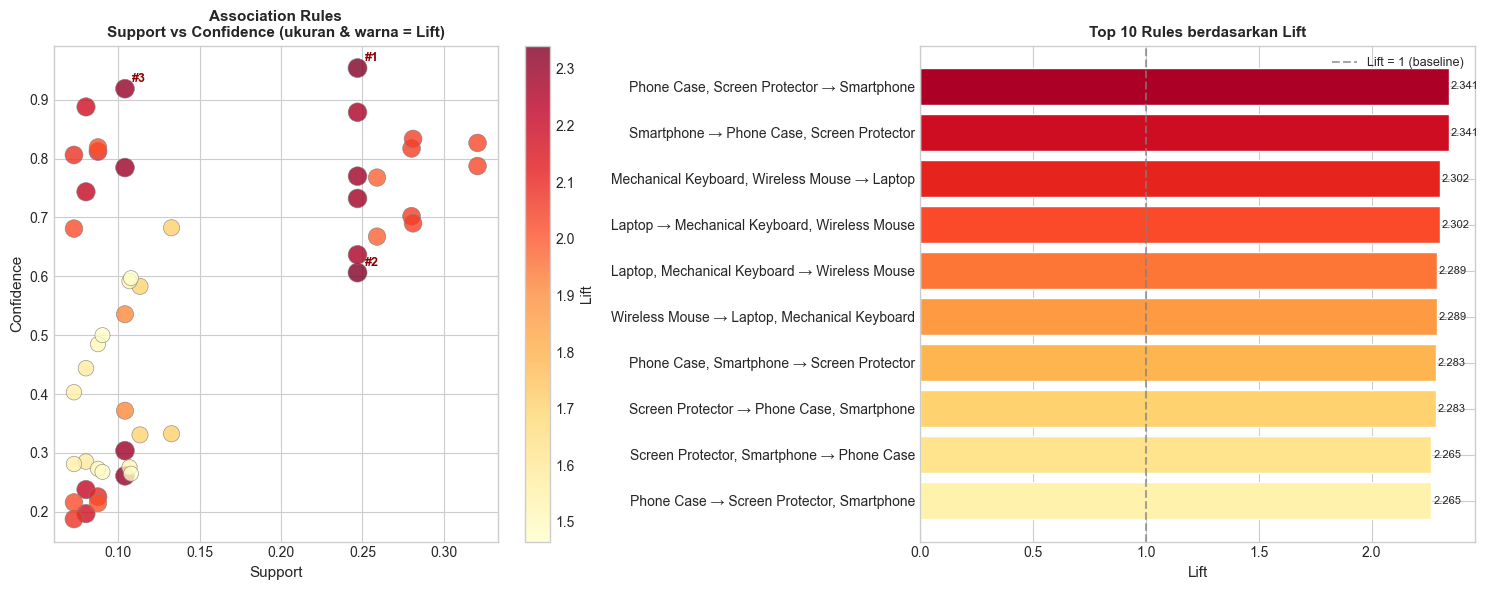

In [75]:
# ── Visualisasi Association Rules ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Support vs Confidence, warna berdasarkan Lift
scatter = axes[0].scatter(
    rules_sorted['support'],
    rules_sorted['confidence'],
    c=rules_sorted['lift'],
    cmap='YlOrRd',
    s=rules_sorted['lift'] * 80,
    alpha=0.8,
    edgecolors='gray',
    linewidths=0.5
)
cbar = plt.colorbar(scatter, ax=axes[0])
cbar.set_label('Lift', fontsize=10)

# Annotate top 3
for i, (_, row) in enumerate(rules_sorted.head(3).iterrows()):
    axes[0].annotate(f"#{i+1}",
                     (row['support'], row['confidence']),
                     fontsize=9, fontweight='bold', color='darkred',
                     xytext=(5, 5), textcoords='offset points')

axes[0].set_xlabel('Support', fontsize=11)
axes[0].set_ylabel('Confidence', fontsize=11)
axes[0].set_title('Association Rules\nSupport vs Confidence (ukuran & warna = Lift)', fontsize=11, fontweight='bold')

# Plot 2: Top 10 Rules berdasarkan Lift
top10 = rules_sorted.head(10).copy()
top10['rule_label'] = top10['antecedents_str'] + ' → ' + top10['consequents_str']
top10['rule_label'] = top10['rule_label'].apply(lambda x: x[:45] + '...' if len(x) > 45 else x)

bar_colors_lift = sns.color_palette('YlOrRd', 10)
bars = axes[1].barh(top10['rule_label'][::-1], top10['lift'][::-1],
                    color=bar_colors_lift, edgecolor='white')
axes[1].axvline(1.0, color='gray', linestyle='--', alpha=0.7, label='Lift = 1 (baseline)')
axes[1].set_xlabel('Lift', fontsize=11)
axes[1].set_title('Top 10 Rules berdasarkan Lift', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)

for bar, val in zip(bars, top10['lift'][::-1]):
    axes[1].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

---
# 🔷 TASK 4 – Analisis & Rekomendasi (Framework B-I-A)
---

## 4.1 Profil Lengkap Tiap Cluster

In [76]:
print("="*65)
print("  PROFIL DETAIL TIAP CLUSTER")
print("="*65)

for c in range(K_FINAL):
    subset = df_clean_indexed[df_clean_indexed['Cluster'] == c]
    print(f"\n{'─'*60}")
    print(f"📌 CLUSTER {c}: {cluster_names[c].upper()}")
    print(f"   Jumlah Pelanggan : {len(subset)} ({len(subset)/len(df_clean_indexed)*100:.1f}%)")
    print(f"   Usia Rata-rata   : {subset['age'].mean():.1f} tahun")
    print(f"   Income Rata-rata : Rp {subset['monthly_income_idr'].mean():>12,.0f}")
    print(f"   Spend Rata-rata  : Rp {subset['monthly_spend_idr'].mean():>12,.0f}")
    print(f"   Spend Ratio      : {subset['spend_ratio'].mean():.2%}")
    print(f"   App Usage        : {subset['app_usage_time_hrs'].mean():.1f} jam/bulan")
    print(f"   Web Visits       : {subset['website_visits_per_month'].mean():.1f} kali/bulan")
    print(f"   Tenure           : {subset['customer_tenure_months'].mean():.1f} bulan")
    print(f"   Support Tickets  : {subset['support_tickets_opened'].mean():.2f} tiket")

  PROFIL DETAIL TIAP CLUSTER

────────────────────────────────────────────────────────────
📌 CLUSTER 0: ESTABLISHED PROFESSIONALS
   Jumlah Pelanggan : 359 (53.3%)
   Usia Rata-rata   : 35.7 tahun
   Income Rata-rata : Rp   11,231,744
   Spend Rata-rata  : Rp    3,246,654
   Spend Ratio      : 29.49%
   App Usage        : 13.4 jam/bulan
   Web Visits       : 16.0 kali/bulan
   Tenure           : 24.0 bulan
   Support Tickets  : 1.97 tiket

────────────────────────────────────────────────────────────
📌 CLUSTER 1: BUDGET-CONSCIOUS CUSTOMERS
   Jumlah Pelanggan : 215 (31.9%)
   Usia Rata-rata   : 22.1 tahun
   Income Rata-rata : Rp    5,813,145
   Spend Rata-rata  : Rp      502,330
   Spend Ratio      : 8.47%
   App Usage        : 49.3 jam/bulan
   Web Visits       : 14.0 kali/bulan
   Tenure           : 23.0 bulan
   Support Tickets  : 0.04 tiket

────────────────────────────────────────────────────────────
📌 CLUSTER 2: HIGH VALUE LOYALISTS
   Jumlah Pelanggan : 100 (14.8%)
   Usia Rata-

In [77]:
# ── Ringkasan Bundling dari Apriori ─────────────────────────────────────
print("\n" + "="*65)
print("  RINGKASAN TOP 3 BUNDLING RECOMMENDATION (APRIORI)")
print("="*65)

bundling_recommendations = []
for i, (_, row) in enumerate(rules_sorted.head(3).iterrows()):
    items = list(row['antecedents']) + list(row['consequents'])
    bundling_recommendations.append(items)
    bundle_str = ' + '.join(items)
    print(f"\n  Bundle #{i+1}: {bundle_str}")
    print(f"    Support   : {row['support']*100:.2f}%  |  Confidence: {row['confidence']*100:.2f}%  |  Lift: {row['lift']:.3f}")


  RINGKASAN TOP 3 BUNDLING RECOMMENDATION (APRIORI)

  Bundle #1: Screen Protector + Phone Case + Smartphone
    Support   : 24.70%  |  Confidence: 95.37%  |  Lift: 2.341

  Bundle #2: Smartphone + Screen Protector + Phone Case
    Support   : 24.70%  |  Confidence: 60.63%  |  Lift: 2.341

  Bundle #3: Wireless Mouse + Mechanical Keyboard + Laptop
    Support   : 10.41%  |  Confidence: 91.87%  |  Lift: 2.302


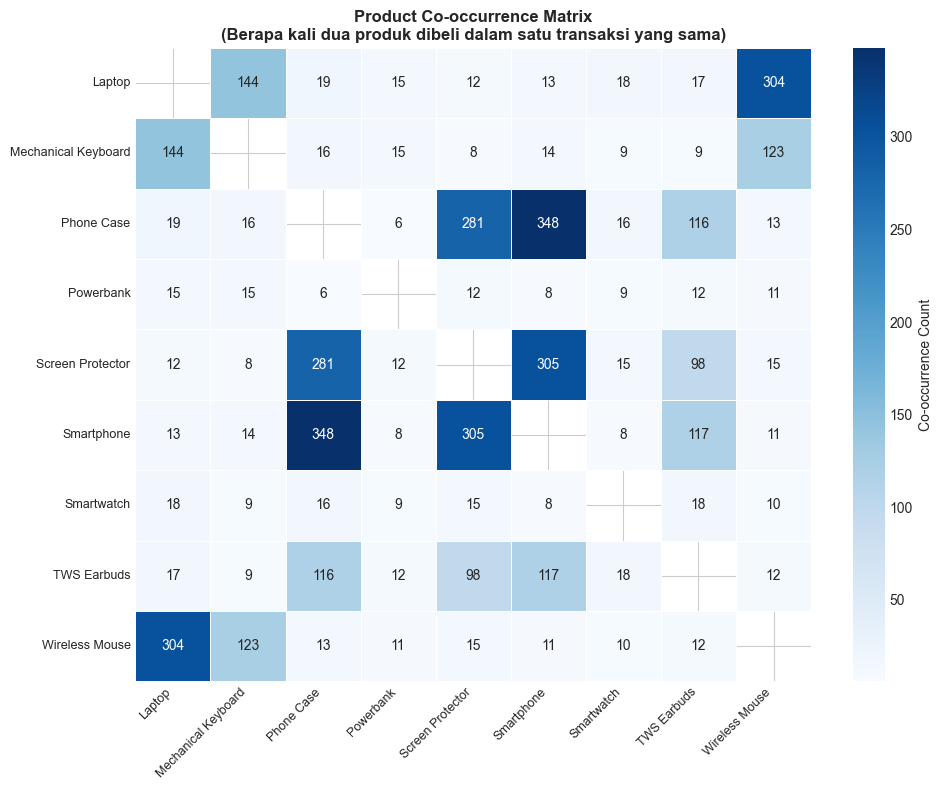

In [78]:
# ── Co-occurrence Matrix (Network-style heatmap) ─────────────────────────
products = sorted(df_trans['product_name'].unique())
cooccur = pd.DataFrame(0, index=products, columns=products)

for order_items in transactions:
    unique_items = list(set(order_items))
    for i in range(len(unique_items)):
        for j in range(len(unique_items)):
            if i != j:
                cooccur.loc[unique_items[i], unique_items[j]] += 1

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.eye(len(products), dtype=bool)
sns.heatmap(cooccur, annot=True, fmt='d', cmap='Blues',
            mask=mask, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Co-occurrence Count'})
ax.set_title('Product Co-occurrence Matrix\n(Berapa kali dua produk dibeli dalam satu transaksi yang sama)',
             fontsize=12, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

## 4.2 Executive Summary – Framework B-I-A

> Format: **Business Context → Insight → Action**

---

### 🏢 Business Context

Tim Marketing Vinix7 selama ini menjalankan kampanye promosi secara *blind* — menyebarkan promo ke semua pelanggan tanpa membedakan siapa mereka. Pendekatan ini tidak efisien karena setiap segmen pelanggan memiliki kapasitas belanja, kebiasaan digital, dan kebutuhan yang berbeda-beda.

---

### 💡 Insight

Dari hasil analisis **K-Means Clustering** (divalidasi dengan Hierarchical Clustering), ditemukan bahwa basis pelanggan Vinix7 terbagi ke dalam **beberapa kelompok** yang memiliki karakteristik berbeda secara signifikan, terutama pada dimensi **income, spending power, masa berlangganan (tenure), dan intensitas digital engagement**. Pelanggan dengan income tinggi dan tenure panjang menunjukkan loyalitas yang kuat, sementara segmen income rendah memiliki spend ratio yang tinggi — menandakan mereka sangat *value-conscious* dan responsif terhadap promosi harga. Di sisi lain, analisis **Market Basket Analysis (Apriori)** mengungkap pola-pola pembelian kombinasi produk yang berulang dan konsisten, sehingga membuka peluang strategi *product bundling* yang targeted.

---

### 🎯 Action Plan per Cluster

**Segmen High Value / Premium**: Fokus pada program loyalitas eksklusif, early access produk baru, dan bundling premium (contoh: *Laptop + Mechanical Keyboard + TWS Earbuds*). Jangan tawarkan diskon besar karena segmen ini tidak price-sensitive — mereka lebih menghargai layanan eksklusif dan pengalaman premium.

**Segmen Digital Enthusiast**: Prioritaskan channel digital (push notification, in-app promo) dengan penawaran bundle yang relevan secara teknologi, seperti *Smartphone + Screen Protector + Phone Case* atau *Smartwatch + Powerbank*. Segmen ini aktif di aplikasi, jadi engagement berbasis fitur aplikasi seperti gamifikasi atau poin rewards akan sangat efektif.

**Segmen Budget-Conscious / Nilai Hemat**: Tawarkan bundling dengan harga terjangkau dan komunikasikan secara eksplisit tentang *value for money*. Contoh bundle: *Phone Case + Screen Protector + Powerbank* dalam paket harga flat. Gunakan channel email atau website (karena web visits mereka tinggi relatif terhadap spend) untuk mengomunikasikan promo flash sale atau cicilan 0%.

**Strategi Cross-Cluster**: Gunakan hasil Apriori untuk mendorong *cross-sell* pada saat checkout — ketika pelanggan membeli satu produk, tampilkan rekomendasi produk komplementer berdasarkan rules yang ditemukan (contoh: beli *Smartphone* → rekomendasikan *Screen Protector + Phone Case*). Ini berlaku untuk semua segmen dan bisa meningkatkan AOV (*Average Order Value*) secara signifikan.

In [ ]:
# ── Final Summary Table ──────────────────────────────────────────────────
print("\n" + "="*65)
print("  RINGKASAN EKSEKUTIF – STRATEGI PER CLUSTER")
print("="*65)

strategies = {
    0: "Loyalty program eksklusif + bundling premium",
    1: "In-app promo + tech bundle + gamifikasi reward",
    2: "Flash sale + bundling hemat + cicilan 0%",
    3: "Email campaign + web retargeting + upsell"
}

# Gunakan strategies yang ada sesuai K_FINAL
for c in range(K_FINAL):
    subset = df_clean_indexed[df_clean_indexed['Cluster'] == c]
    strategy = strategies.get(c, "Targeted campaign berbasis segmen")
    print(f"\nCluster {c} – {cluster_names[c]}")
    print(f"  Ukuran    : {len(subset)} pelanggan ({len(subset)/len(df_clean_indexed)*100:.1f}%)")
    print(f"  Income    : Rp {subset['monthly_income_idr'].mean():>10,.0f} (avg)")
    print(f"  Spend     : Rp {subset['monthly_spend_idr'].mean():>10,.0f} (avg)")
    print(f"  Strategi  : {strategy}")

print(f"\n{'─'*65}")
print("📦 BUNDLING TERKUAT (Apriori):")
for i, bundle in enumerate(bundling_recommendations):
    print(f"  Bundle #{i+1}: {' + '.join(bundle)}")

print(f"\nRekomendasi bundling ini didasarkan pada analisis asosiasi yang menunjukkan bahwa produk-produk ini sering dibeli bersamaan, dengan lift yang signifikan di atas 1.0, menandakan peluang cross-selling yang kuat.")


  RINGKASAN EKSEKUTIF – STRATEGI PER CLUSTER

Cluster 0 – Established Professionals
  Ukuran    : 359 pelanggan (53.3%)
  Income    : Rp 11,231,744 (avg)
  Spend     : Rp  3,246,654 (avg)
  Strategi  : Loyalty program eksklusif + bundling premium

Cluster 1 – Budget-Conscious Customers
  Ukuran    : 215 pelanggan (31.9%)
  Income    : Rp  5,813,145 (avg)
  Spend     : Rp    502,330 (avg)
  Strategi  : In-app promo + tech bundle + gamifikasi reward

Cluster 2 – High Value Loyalists
  Ukuran    : 100 pelanggan (14.8%)
  Income    : Rp 25,534,244 (avg)
  Spend     : Rp 11,454,601 (avg)
  Strategi  : Flash sale + bundling hemat + cicilan 0%

─────────────────────────────────────────────────────────────────
📦 BUNDLING TERKUAT (Apriori):
  Bundle #1: Screen Protector + Phone Case + Smartphone
  Bundle #2: Smartphone + Screen Protector + Phone Case
  Bundle #3: Wireless Mouse + Mechanical Keyboard + Laptop

✅ Analisis selesai! Semua visualisasi tersimpan sebagai file PNG.
